## ***Initials***

In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# ***Add the Feature: 'Neighborhood' on each Business Entry***

***NOTE:*** I did this using a ***buffer via QGIS*** (i think), because some points fell just short of the boundaries but they belonged to a neighborhood. For some reason ***I can not recreate the result programatically*** despite the buffer value i choose. But this is ***not important***, because the file ***business_data.csv*** already hass both the Municipal Community and the Neihgborhood of each entry, i do not need to add this feature again (hopefully)

## ***Load the Data***

In [2]:
# --- 1. Load the business CSV ---
business_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\2. Joining - Business - Municipal Community Data\\Exrtacted CSV Files\\business_data.csv")

In [3]:
print(business_df.shape)
print(business_df.columns)
business_df.head()

(3906, 15)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Δημοτική Κοινότητα Βόλου
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Δημοτική Κοινότητα Βόλου
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Δημοτική Κοινότητα Βόλου
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Δημοτική Κοινότητα Βόλου
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Δημοτική Κοινότητα Βόλου


In [32]:
# --- 2. Convert to GeoDataFrame ---
business_df['geometry'] = business_df.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)

In [33]:
business_gdf = gpd.GeoDataFrame(business_df, geometry='geometry', crs="EPSG:4326")

In [34]:
# --- 3. Load the polygon layer (the exported shapefile from QGIS) ---
admin_gdf = gpd.read_file("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\3. Data -  Smaller Spatial Units\\1. Neighborhoods\\Shapefiles\\2. Neighborhood Polygons\\final_voronoi_output.gpkg")

In [35]:
admin_gdf = admin_gdf.to_crs("EPSG:4326")

In [36]:
business_gdf = business_gdf.to_crs(epsg=2100)
admin_gdf = admin_gdf.to_crs(epsg=2100)

business_gdf['geometry'] = business_gdf.geometry.buffer(5)

## ***Perfrom the Spatial Join to get the Municipal Community of the Entry***

In [37]:
# --- 4. Spatial join ---
joined = gpd.sjoin(business_gdf, admin_gdf, how="left", predicate="intersects")

In [38]:
columns_to_drop = ['name_el', 'int_name', 'addr_postc', 'alt_name',	'layer', 'path', 'point_id', 'centroid_x', 'centroid_y',
                    'area', 'place', 'name_en', 'name_de', 'name_ca', 'wikipedia', 'wikidata', 'population', 'name_ru',
                    'geometry',	'index_right',	'community', 'name', 'method', 'full_id',	'osm_id', 'osm_type', 'name_fr']
joined.drop(columns=columns_to_drop, inplace=True)

In [39]:
joined.rename(columns={"point_name": "Neighborhood"}, inplace=True)

In [40]:
print(len(joined))
joined.head()

3971


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community,Neighborhood
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Δημοτική Κοινότητα Βόλου,Νέες Παγασές
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Δημοτική Κοινότητα Βόλου,Αϊβαλιώτικα
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Δημοτική Κοινότητα Βόλου,Νέες Παγασές
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Δημοτική Κοινότητα Βόλου,Νέες Παγασές
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Δημοτική Κοινότητα Βόλου,Νέες Παγασές


## ***Save the Data***

In [123]:
joined.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data.csv", index=False)

## ***Sanity Checks***

In [175]:
df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data.csv")
print(len(df))
df.head()

3906


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community,Neighborhood
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Δημοτική Κοινότητα Βόλου,Νέες Παγασές
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Δημοτική Κοινότητα Βόλου,Αϊβαλιώτικα
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Δημοτική Κοινότητα Βόλου,Νέες Παγασές
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Δημοτική Κοινότητα Βόλου,Νέες Παγασές
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Δημοτική Κοινότητα Βόλου,Νέες Παγασές


In [176]:
print("Unique neighborhoods:", df['Neighborhood'].nunique())
print("Neighborhood names:", df['Neighborhood'].unique())

Unique neighborhoods: 39
Neighborhood names: ['Νέες Παγασές' 'Αϊβαλιώτικα' 'Νεάπολη' 'Δημίνι' 'Μεταμόρφωση' 'Παλιά'
 'Άγιος Νικόλαος' 'Οξυγόνο' 'Άγιος Κωνσταντίνος' 'Νέα Δημητριάδα'
 'Άλλη Μεριά' 'Καραγάτς' 'Άγιοι Ανάργυροι' 'Νέο Δέλτα' 'Χιλιαδού'
 'Άγιος Βασίλειος' nan 'Άγιος Γεώργιος' 'Ανάληψη' 'Ιωλκός' 'Πορταριά'
 'Αγία Κυριακή' 'Αγία Παρασκευή' 'Ανακασιά' 'Άγιος Ονούφριος' 'Άνω Βόλος'
 'Μελισσάτικα' 'Μακρυνίτσα' 'Αστέρια Αγριάς' 'Δημητριάδα' 'Μάραθος'
 'Μικροθήβες' 'Σέσκλο' 'Κάτω Λεχώνια' 'Άγιος Στέφανος' 'Άνω Λεχώνια'
 'Βελανιδιά' 'Δράκεια' 'Κριθαριά' 'Άγιος Βλάσιος']


Neighborhood
Άγιος Νικόλαος        551
Μεταμόρφωση           522
Νέο Δέλτα             490
Ανάληψη               380
Οξυγόνο               220
Νεάπολη               187
Άγιος Βασίλειος       182
Άγιοι Ανάργυροι       179
Παλιά                 154
Άγιος Κωνσταντίνος    139
Αγία Παρασκευή        110
Δημητριάδα            109
Άγιος Γεώργιος         92
Καραγάτς               88
Νέα Δημητριάδα         83
Αστέρια Αγριάς         81
Χιλιαδού               73
Νέες Παγασές           46
Δημίνι                 40
Αϊβαλιώτικα            37
Αγία Κυριακή           36
Ανακασιά               24
Σέσκλο                  8
Μικροθήβες              8
Άλλη Μεριά              7
Μελισσάτικα             5
Κάτω Λεχώνια            4
Πορταριά                4
Μακρυνίτσα              4
Ιωλκός                  4
Άνω Βόλος               3
Άγιος Ονούφριος         2
Άγιος Στέφανος          2
Άνω Λεχώνια             2
Δράκεια                 2
Μάραθος                 1
Βελανιδιά               1
Κριθαριά                1

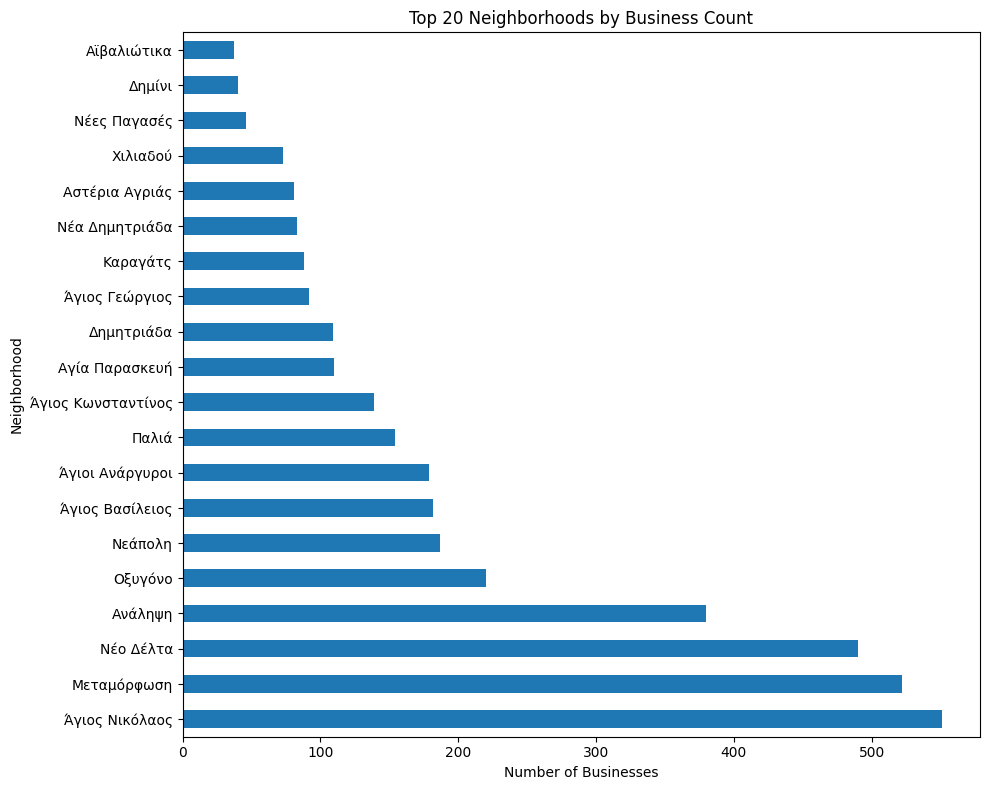

In [177]:
neighborhood_counts = df['Neighborhood'].value_counts()
print(neighborhood_counts)

neighborhood_counts.head(20).plot(kind='barh', figsize=(10, 8))  # top 20 by count
plt.xlabel('Number of Businesses')
plt.title('Top 20 Neighborhoods by Business Count')
plt.tight_layout()
plt.show()

In [178]:
print(df['Neighborhood'].isna().sum())

24


In [174]:
df_null_neighborhoods = df[df['Neighborhood'].isna()]
df_null_neighborhoods = df_null_neighborhoods[['Name', 'Longitude', 'Latitude', 'Municipal_Community']]
df_null_neighborhoods.to_csv("df_null_neighborhood.csv", index=False)

There are some null values. This is normal for the entries that are actually outside of the Volos Municipality, because these are the Neighborhoods I use only. I believe i can later ***drop*** these entries

In [180]:
# Keep only rows where Neighborhood is not null
filtered = df[df['Neighborhood'].notna()]
print("Filtered DataFrame length:", len(filtered))

Filtered DataFrame length: 3882


In [182]:
filtered.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data.csv", index=False)

# ***Join the Business Entries with the Municipal Community AND the Neighborhood***

## ***Load the Data***

In [70]:
df_businesses = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data.csv")

In [71]:
print(df_businesses.shape)
df_businesses.head()

(3882, 16)


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community,Neighborhood
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Municipal Community of Volos,Nees Pagases
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Municipal Community of Volos,Aivaliotika
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Municipal Community of Volos,Nees Pagases
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Municipal Community of Volos,Nees Pagases
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Municipal Community of Volos,Nees Pagases


In [72]:
df_municipal_communities = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\4. Exploratory Data Analysis\\Extracted CSV Files\\ELSTAT-demographic-economic.csv")
print(df_municipal_communities.shape)
df_municipal_communities.head()

(76, 23)


,Unnamed: 0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Population,Άγαμοι_pct,Έγγαμοι_pct,Χήροι_pct,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Δημοτική Κοινότητα Βόλου,Municipal Community of Volos,85806,0.4032,0.4630,0.0809,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,1,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Αγριάς,Municipal Community of Agria,4926,0.3577,0.5173,0.0796,...,0.2359,0.4670,0.3341,0.1987,0.1555,0.3955,0.0816,0.1864,0.7314,3.737347
2,2,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Δρακείας,Municipal Community of Drakeia,369,0.3496,0.4580,0.1382,...,0.2873,0.6667,0.2493,0.0840,0.1439,0.3767,0.4545,0.0826,0.4628,21.683415
3,3,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Διμηνίου,Municipal Community of Dimini,2101,0.3889,0.5007,0.0776,...,0.2080,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451
4,4,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Σέσκλου,Municipal Community of Sesklos,899,0.3960,0.5184,0.0645,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725


In [73]:
df_neighborhoods = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\3. Data -  Smaller Spatial Units\\1. Neighborhoods\\Extracted CSV Files\\neighborhoods_enriched.csv")
print(df_neighborhoods.shape)
df_neighborhoods.head()

(48, 12)


,Municipal Community,Neighborhood_Greek,Neighborhood,Centroid_x,Centroid_y,Neighborhood_Area_km2,Geometry,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Δημοτική Κοινότητα Διμηνίου,Δημίνι,Dimini,22.882945,39.349112,37.344776,MULTIPOLYGON (((406692.718139543 4357521.85294...,6.154015,5.418577,0.443434,1.569912,4.273031
1,Δημοτική Κοινότητα Σέσκλου,Χρυσή Ακτή Παναγίας,Xrisi Akti Panagias,22.836899,39.305430,9.983032,MULTIPOLYGON (((396744.165394512 4351195.65810...,11.932475,11.015584,2.299921,2.410375,10.100771
2,Δημοτική Κοινότητα Σέσκλου,Σέσκλο,Sesklo,22.838168,39.353051,27.367312,MULTIPOLYGON (((400839.361742302 4353031.79092...,9.814666,9.191001,0.482308,4.965561,7.989610
3,Δημοτική Κοινότητα Βόλου,Άγιοι Ανάργυροι,Agioi Anargiroi,22.924059,39.366937,0.774436,MULTIPOLYGON (((406589.250339913 4357224.83344...,2.296184,1.978856,0.058142,0.063879,0.866021
4,Δημοτική Κοινότητα Βόλου,Αϊβαλιώτικα,Aivaliotika,22.922660,39.343696,4.848904,MULTIPOLYGON (((407619.510540358 4356306.42684...,3.508166,2.529372,0.224486,0.246542,1.913456


## ***Merge Business Entries with Municipal Communities***

In [60]:
# Create a copy of df_municipal_communities with renamed column for merge
df_municipal_communities = df_municipal_communities.rename(
    columns={'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ': 'Municipal_Community'}
)

In [61]:
# Step 1: Join business entries with municipal community features
df = pd.merge(
    df_businesses,
    df_municipal_communities,
    on='Municipal_Community',
    how='left'  # use 'left' to preserve all business entries
)

In [62]:
print(df.shape)
print(df.columns)
df.head()

(3882, 38)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'Unnamed: 0', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ',
       'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ', 'Population',
       'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct', 'Διαζευγμένοι_pct',
       'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct', 'low_education_pct',
       'medium_education_pct', 'high_education_pct', 'unemployment_rate',
       'labor_force_participation_rate', 'primary_sector_pct',
       'secondary_sector_pct', 'tertiary_sector_pct', 'Area_km2'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807


## ***Merge Business Entries with Neighborhoods***

In [ ]:
# Step 2: Join with neighborhood features
df = pd.merge(
    business_df,
    df_neighborhoods,
    on='Neighborhood',
    how='left'
)

# df = pd.merge(
#     df_businesses,
#     df_neighborhoods,
#     on='Neighborhood',
#     how='left'
# )

In [ ]:
# drop unnecessary features
df.drop(columns=['Geometry', 'Centroid_x','Centroid_y', 'Municipal Community', 'Unnamed: 0', 'Neighborhood_Greek','ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ'], inplace=True)
#df.drop(columns=['Municipal Community', 'Neighborhood_Greek','Centroid_x', 'Centroid_y', 'Geometry'], inplace=True)

In [91]:
print(df.shape)
print(df.columns)
df.head()

(3882, 22)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,NACE Code,NACE Description (EN),Municipal_Community,Neighborhood,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,47.76,"Retail sale of flowers, plants, seeds, fertili...",Municipal Community of Volos,Nees Pagases,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,47.59,"Retail sale of furniture, lighting equipment a...",Municipal Community of Volos,Aivaliotika,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,94.91,Activities of religious organisations,Municipal Community of Volos,Nees Pagases,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,49.41,Freight transport by road,Municipal Community of Volos,Nees Pagases,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,47.11,Retail sale in non-specialised stores with foo...,Municipal Community of Volos,Nees Pagases,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331


## ***Save the Data***

In [ ]:
df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data_ELSTAT_neighborhood.csv", index=False)
#df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data_neighborhood.csv", index=False)

## ***Sanity Checks***

In [2]:
df_old = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data_ELSTAT_neighborhood.csv")

In [93]:
df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data_neighborhood.csv")

In [3]:
# Preview joined data
print(df_old.shape)
print(df_old.columns)

(3882, 42)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


In [94]:
# Preview joined data
print(df.shape)
print(df.columns)

(3882, 22)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


In [96]:
df.isnull().sum().sum()


11021

In [97]:
df_old.isnull().sum().sum()

11021